In [408]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [409]:
PROCESSED_DATA_DIR = Path("../data/processed")

In [410]:
leads_df = pd.read_csv(PROCESSED_DATA_DIR / "leads.csv", sep=",", encoding="utf-8", parse_dates=["date"])

sales_df = pd.read_csv(PROCESSED_DATA_DIR / "sales.csv", sep=",", encoding="utf-8", parse_dates=["date"])

info_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "info_actions.csv", sep=",", encoding="utf-8")

In [411]:
merge_keys = ["course_id", "local", "modality", "date"]

active_courses_df = info_actions_df.loc[info_actions_df["active"]].copy()

commercial_analysis = (
    leads_df
    .merge(
        sales_df,
        how="outer",
        on=["course_id", "local", "modality", "date"],
        validate="one_to_one"
    )
    .fillna({
        "total_leads": 0,
        "total_sales": 0
    })
    .astype({
        "total_leads": "int64",
        "total_sales": "int64"
    })
    .merge(
        active_courses_df,
        how="inner",
        on="course_id",
        validate="many_to_one"
    )
)

commercial_analysis = commercial_analysis[["course_id", "course_name", "course_area", "local", "modality", "date", "total_sales", "total_leads"]]

commercial_analysis

,course_id,course_name,course_area,local,modality,date,total_sales,total_leads
0,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-03-20,11,44
1,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-03-27,21,79
2,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-04-17,5,19
3,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-04-24,9,33
4,CYB,Cibersegurança Básica,Informática,Centro 1,Hybrid,2023-05-08,6,22
...,...,...,...,...,...,...,...,...
23981,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-10-26,21,67
23982,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-11-02,20,66
23983,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-11-09,24,77
23984,VND,Vendas e Negociação,Comercial,Centro 5,Online,2026-11-16,12,39


In [412]:
def summarize_commercial(df, group_columns):
    summary = (
        df
        .groupby(group_columns, as_index=False)
        .agg(
            leads_count=("total_leads", "sum"),
            sales_count=("total_sales", "sum")
        )
        .assign(
            pct_leads=lambda data:
                data["leads_count"]
                .div(data["leads_count"].sum())
                .mul(100)
                .round(1),

            pct_sales=lambda data:
                data["sales_count"]
                .div(data["sales_count"].sum())
                .mul(100)
                .round(1),

            conversion_rate=lambda data:
                data["sales_count"]
                .div(data["leads_count"])
                .mul(100)
                .fillna(0)
                .round(1)
        )
        .sort_values(
            by="leads_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return summary

In [413]:
commercial_course_count = summarize_commercial(
    commercial_analysis,
    ["course_id", "course_name"]
)

commercial_course_count

,course_id,course_name,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,CYB,Cibersegurança Básica,66543,18683,8.4,7.6,28.1
1,PBI,Power BI e Visualização de Dados,61525,19047,7.7,7.8,31.0
2,EXC,Excel Aplicado à Gestão,44103,14732,5.5,6.0,33.4
3,PYT,Introdução à Programação em Python,43917,11974,5.5,4.9,27.3
4,SST,Saúde e Segurança no Trabalho,38797,12799,4.9,5.2,33.0
5,SEG,Segurança no Trabalho,37063,12505,4.7,5.1,33.7
6,GER,Geriatria e Apoio ao Idoso,35497,11040,4.5,4.5,31.1
7,LID,Liderança e Comunicação,34561,9980,4.3,4.1,28.9
8,MNT,Manutenção Industrial Básica,33758,9849,4.2,4.0,29.2
9,LOG,Logística e Gestão de Armazém,33364,11027,4.2,4.5,33.1


In [414]:
commercial_local_count = summarize_commercial(
    commercial_analysis,
    ["local"]
)

commercial_local_count

,local,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,Centro 2,167758,53151,21.1,21.7,31.7
1,Centro 1,159519,48598,20.1,19.9,30.5
2,Centro 3,157033,46426,19.8,19.0,29.6
3,Centro 4,155610,49908,19.6,20.4,32.1
4,Centro 5,154930,46604,19.5,19.0,30.1


In [415]:
commercial_modality_count = summarize_commercial(
    commercial_analysis,
    ["modality"]
)

commercial_modality_count

,modality,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,In-person,331313,103344,41.7,42.2,31.2
1,Hybrid,262264,80655,33.0,33.0,30.8
2,Online,201273,60688,25.3,24.8,30.2


In [416]:
commercial_course_area_count = summarize_commercial(
    commercial_analysis,
    ["course_area"]
)

commercial_course_area_count

,course_area,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,Informática,216088,64436,27.2,26.3,29.8
1,Segurança,121720,39492,15.3,16.1,32.4
2,Gestão,92474,25982,11.6,10.6,28.1
3,Saúde,59611,18704,7.5,7.6,31.4
4,Saúde e Segurança,51089,16600,6.4,6.8,32.5
5,Alimentar,50410,17230,6.3,7.0,34.2
6,Turismo,44704,14129,5.6,5.8,31.6
7,Manutenção,33758,9849,4.2,4.0,29.2
8,Logística,33364,11027,4.2,4.5,33.1
9,Comercial,33008,10108,4.2,4.1,30.6


In [417]:
commercial_course_local_count = summarize_commercial(
    commercial_analysis,
    ["course_id", "course_name", "local"]
)

commercial_course_local_count

,course_id,course_name,local,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,CYB,Cibersegurança Básica,Centro 4,17325,5078,2.2,2.1,29.3
1,PBI,Power BI e Visualização de Dados,Centro 4,16580,5382,2.1,2.2,32.5
2,PBI,Power BI e Visualização de Dados,Centro 2,15455,4915,1.9,2.0,31.8
3,CYB,Cibersegurança Básica,Centro 2,14602,4227,1.8,1.7,28.9
4,PYT,Introdução à Programação em Python,Centro 2,12791,3615,1.6,1.5,28.3
...,...,...,...,...,...,...,...,...
115,SOC,Socorrismo Básico,Centro 1,2924,853,0.4,0.3,29.2
116,SOC,Socorrismo Básico,Centro 2,2811,874,0.4,0.4,31.1
117,HOT,Housekeeping e Operações Hoteleiras,Centro 4,2651,891,0.3,0.4,33.6
118,GES,Gestão de Equipas,Centro 3,2646,698,0.3,0.3,26.4


In [418]:
commercial_course_modality_count = summarize_commercial(
    commercial_analysis,
    ["course_id", "course_name", "modality"]
)

commercial_course_modality_count

,course_id,course_name,modality,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,MNT,Manutenção Industrial Básica,In-person,33758,9849,4.2,4.0,29.2
1,PBI,Power BI e Visualização de Dados,Online,31037,9645,3.9,3.9,31.1
2,CYB,Cibersegurança Básica,Online,30660,8617,3.9,3.5,28.1
3,CYB,Cibersegurança Básica,Hybrid,23999,6745,3.0,2.8,28.1
4,GER,Geriatria e Apoio ao Idoso,In-person,22976,7150,2.9,2.9,31.1
5,EXC,Excel Aplicado à Gestão,Online,21532,7237,2.7,3.0,33.6
6,PRI,Primeiros Socorros,In-person,20696,7107,2.6,2.9,34.3
7,LOG,Logística e Gestão de Armazém,In-person,20692,6833,2.6,2.8,33.0
8,PBI,Power BI e Visualização de Dados,Hybrid,20423,6299,2.6,2.6,30.8
9,PYT,Introdução à Programação em Python,Online,20152,5539,2.5,2.3,27.5


In [419]:
commercial_local_modality_count = summarize_commercial(
    commercial_analysis,
    ["local", "modality"]
)

commercial_local_modality_count

,local,modality,leads_count,sales_count,pct_leads,pct_sales,conversion_rate
0,Centro 5,In-person,70567,21463,8.9,8.8,30.4
1,Centro 3,In-person,69985,20973,8.8,8.6,30.0
2,Centro 1,In-person,68101,21090,8.6,8.6,31.0
3,Centro 2,In-person,63710,20601,8.0,8.4,32.3
4,Centro 4,In-person,58950,19217,7.4,7.9,32.6
5,Centro 2,Hybrid,56791,17910,7.1,7.3,31.5
6,Centro 3,Hybrid,53407,15788,6.7,6.5,29.6
7,Centro 1,Hybrid,53360,16248,6.7,6.6,30.4
8,Centro 4,Hybrid,51241,16391,6.4,6.7,32.0
9,Centro 5,Hybrid,47465,14318,6.0,5.9,30.2


In [420]:
def plot_commercial_overview(charts, title, ylabel, nrows=2, ncols=2, figsize=(13, 9)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    metric_columns = {
        "leads": {
            "value": "leads_count",
            "percentage": "pct_leads"
        },
        "sales": {
            "value": "sales_count",
            "percentage": "pct_sales"
        },
        "conversion": {
            "value": "conversion_rate",
            "percentage": None
        },
        "score": {
            "value": "commercial_count",
            "percentage": "pct_commercial"
        }
    }

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = chart["df"].copy()

        metric = chart["metric"]

        value_column = metric_columns[metric]["value"]
        percentage_column = metric_columns[metric]["percentage"]

        if chart.get("sort", True):
            plot_df = plot_df.sort_values(by=value_column, ascending=False)

        if "top_n" in chart:
            plot_df = plot_df.head(
                chart["top_n"]
            )

        if "label_columns" in chart:
            categories = (
                plot_df[chart["label_columns"]]
                .astype(str)
                .agg(" | ".join, axis=1)
            )

        else:
            categories = (
                plot_df[chart["label_column"]]
                .astype(str)
            )

        values = plot_df[value_column]

        bars = ax.bar(
            categories,
            values
        )

        if metric == "conversion":

            labels = [
                f"{value:.1f}%"
                for value in values
            ]

        elif metric == "score":

            percentages = plot_df[percentage_column]

            labels = [
                f"{value:.0f}\n({percentage:.1f}%)"
                for value, percentage
                in zip(values, percentages)
            ]

        else:

            percentages = plot_df[percentage_column]

            labels = [
                f"{value / 1000:.1f}K\n({percentage:.1f}%)"
                for value, percentage
                in zip(values, percentages)
            ]

        ax.bar_label(
            bars,
            labels=labels,
            padding=4,
            fontsize=8
        )

        ax.set_title(
            chart["title"],
            loc="left",
            fontweight="bold",
            pad=25
        )

        ax.text(
            0,
            1.02,
            chart["description"],
            transform=ax.transAxes,
            fontsize=9,
            color="#6B7280"
        )

        ax.set_facecolor("#FFFFFF")
        ax.set_ylabel(ylabel)

        maximum_value = values.max()

        ax.set_ylim(
            0,
            maximum_value * 1.25
            if maximum_value > 0
            else 1
        )

        ax.tick_params(
            axis="x",
            rotation=45
        )

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    for ax in axes.flat[len(charts):]:
        ax.set_visible(False)

    plt.tight_layout(
        rect=[0, 0, 1, 0.95],
        h_pad=3
    )

    plt.show()

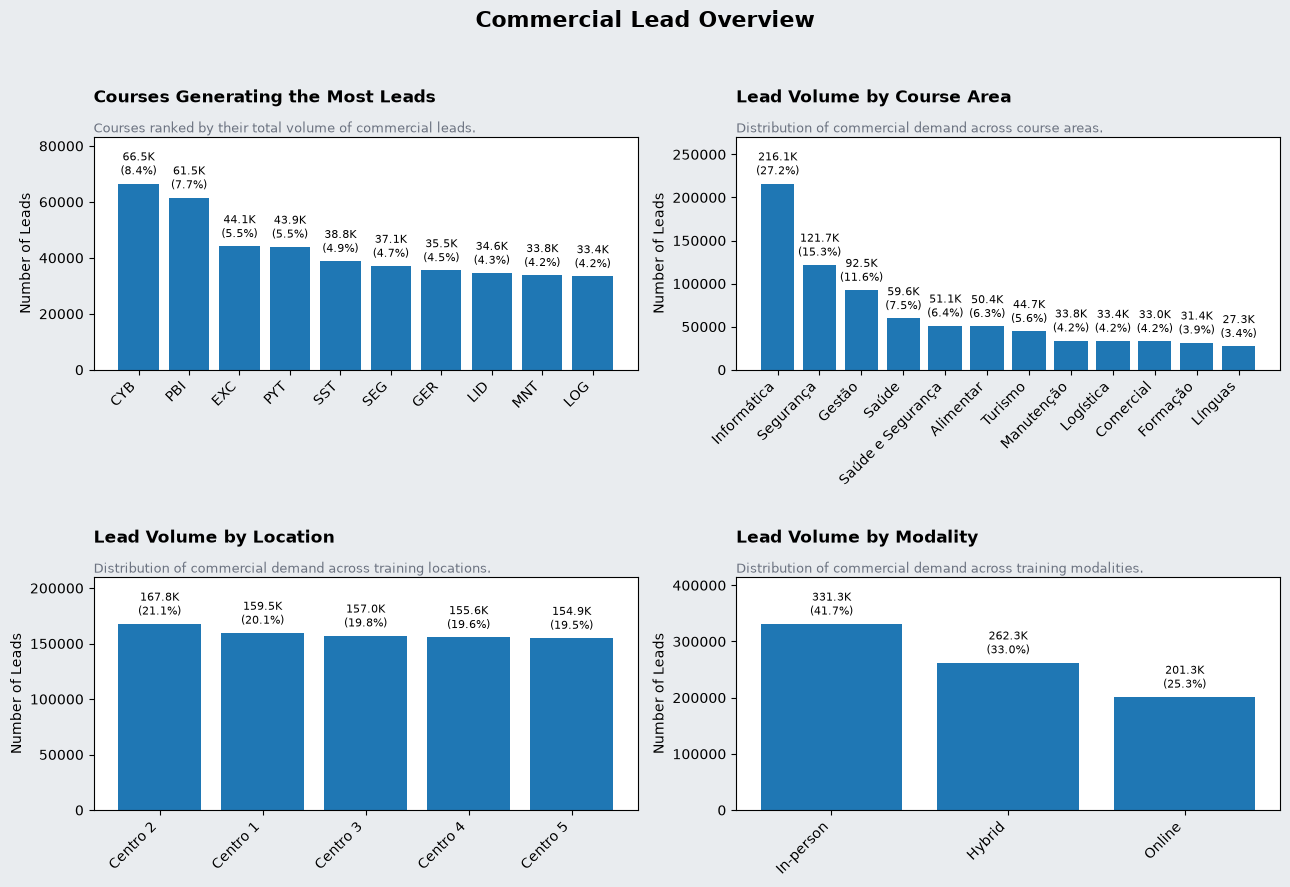

In [421]:
commercial_leads_overview_charts = {
    "course": {
        "df": commercial_course_count,
        "label_column": "course_id",
        "metric": "leads",
        "title": "Courses Generating the Most Leads",
        "description": (
            "Courses ranked by their total volume of commercial leads."
        ),
        "top_n": 10
    },

    "course_area": {
        "df": commercial_course_area_count,
        "label_column": "course_area",
        "metric": "leads",
        "title": "Lead Volume by Course Area",
        "description": (
            "Distribution of commercial demand across course areas."
        )
    },

    "local": {
        "df": commercial_local_count,
        "label_column": "local",
        "metric": "leads",
        "title": "Lead Volume by Location",
        "description": (
            "Distribution of commercial demand across training locations."
        )
    },

    "modality": {
        "df": commercial_modality_count,
        "label_column": "modality",
        "metric": "leads",
        "title": "Lead Volume by Modality",
        "description": (
            "Distribution of commercial demand across training modalities."
        )
    }
}

plot_commercial_overview(
    charts=commercial_leads_overview_charts,
    title="Commercial Lead Overview",
    ylabel="Number of Leads",
    nrows=2,
    ncols=2,
    figsize=(13, 9)
)

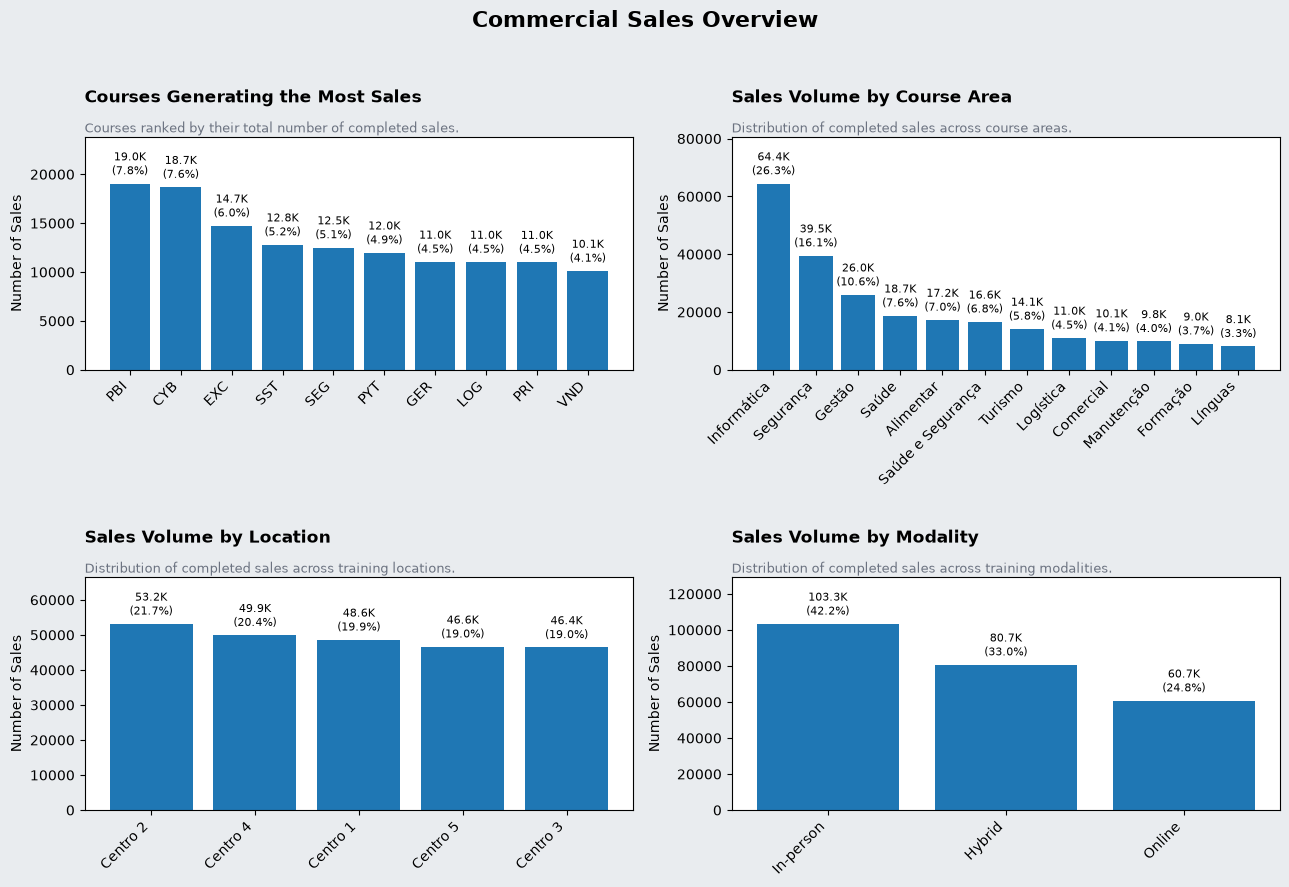

In [422]:
commercial_sales_overview_charts = {
    "course": {
        "df": commercial_course_count,
        "label_column": "course_id",
        "metric": "sales",
        "title": "Courses Generating the Most Sales",
        "description": (
            "Courses ranked by their total number of completed sales."
        ),
        "top_n": 10
    },

    "course_area": {
        "df": commercial_course_area_count,
        "label_column": "course_area",
        "metric": "sales",
        "title": "Sales Volume by Course Area",
        "description": (
            "Distribution of completed sales across course areas."
        )
    },

    "local": {
        "df": commercial_local_count,
        "label_column": "local",
        "metric": "sales",
        "title": "Sales Volume by Location",
        "description": (
            "Distribution of completed sales across training locations."
        )
    },

    "modality": {
        "df": commercial_modality_count,
        "label_column": "modality",
        "metric": "sales",
        "title": "Sales Volume by Modality",
        "description": (
            "Distribution of completed sales across training modalities."
        )
    }
}

plot_commercial_overview(
    charts=commercial_sales_overview_charts,
    title="Commercial Sales Overview",
    ylabel="Number of Sales",
    nrows=2,
    ncols=2,
    figsize=(13, 9)
)

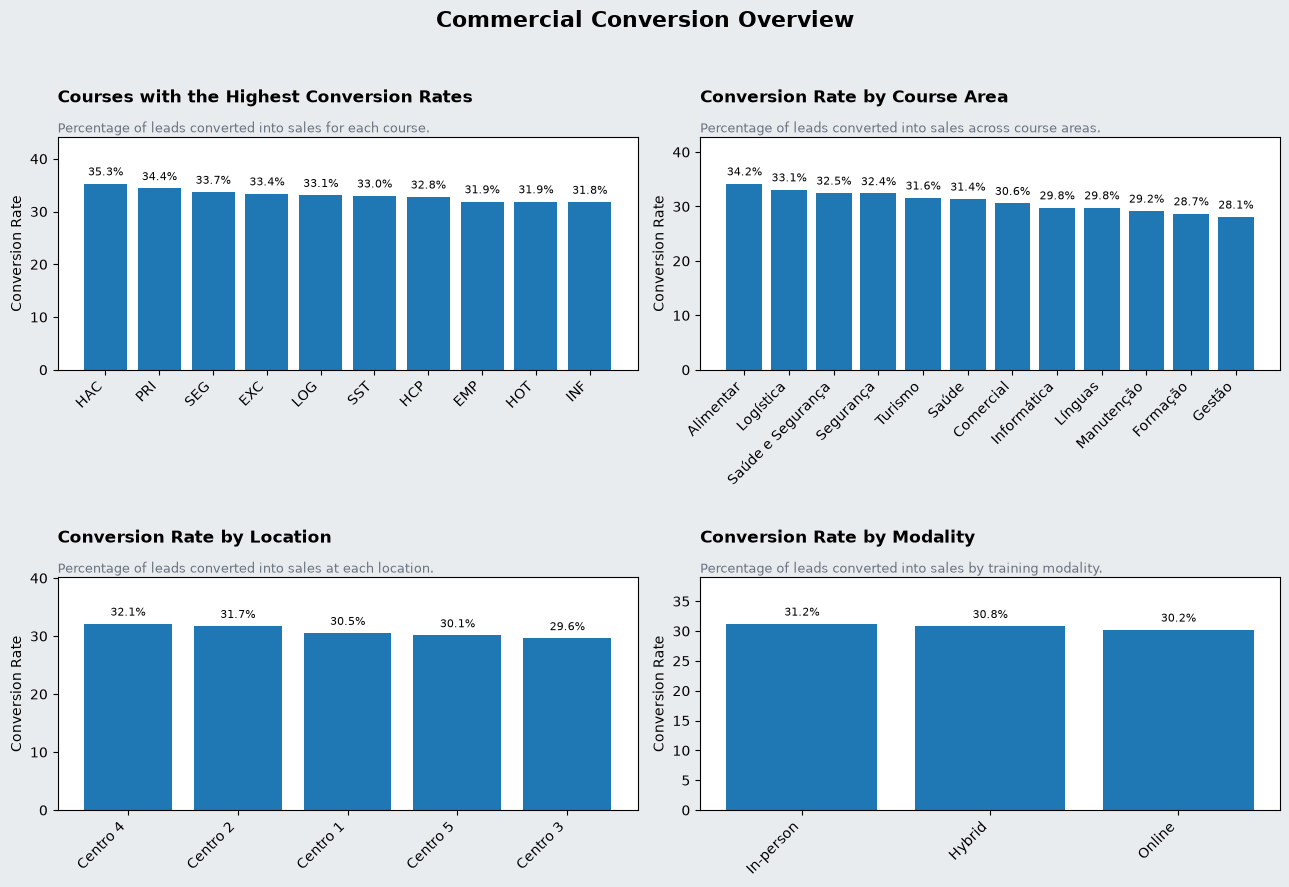

In [423]:
commercial_conversion_overview_charts = {
    "course": {
        "df": commercial_course_count,
        "label_column": "course_id",
        "metric": "conversion",
        "title": "Courses with the Highest Conversion Rates",
        "description": (
            "Percentage of leads converted into sales for each course."
        ),
        "top_n": 10
    },

    "course_area": {
        "df": commercial_course_area_count,
        "label_column": "course_area",
        "metric": "conversion",
        "title": "Conversion Rate by Course Area",
        "description": (
            "Percentage of leads converted into sales across course areas."
        )
    },

    "local": {
        "df": commercial_local_count,
        "label_column": "local",
        "metric": "conversion",
        "title": "Conversion Rate by Location",
        "description": (
            "Percentage of leads converted into sales at each location."
        )
    },

    "modality": {
        "df": commercial_modality_count,
        "label_column": "modality",
        "metric": "conversion",
        "title": "Conversion Rate by Modality",
        "description": (
            "Percentage of leads converted into sales by training modality."
        )
    }
}

plot_commercial_overview(
    charts=commercial_conversion_overview_charts,
    title="Commercial Conversion Overview",
    ylabel="Conversion Rate",
    nrows=2,
    ncols=2,
    figsize=(13, 9)
)

In [424]:
group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


commercial_weekly_raw_df = (
    commercial_analysis
    .loc[
        :,
        group_columns + [
            "date",
            "total_leads",
            "total_sales"
        ]
    ]
    .assign(
        date=lambda df:
            pd.to_datetime(df["date"])
    )
    .groupby(
        group_columns + ["date"],
        as_index=False
    )
    .agg(
        total_leads=(
            "total_leads",
            "sum"
        ),

        total_sales=(
            "total_sales",
            "sum"
        )
    )
)

commercial_features_base = commercial_weekly_raw_df.copy()

In [425]:
recent_weeks = 13


reference_week = (
    commercial_features_base["date"]
    .max()
)


last_13w_start_week = (
    reference_week
    - pd.Timedelta(
        weeks=recent_weeks - 1
    )
)


reference_date = reference_week

In [426]:
commercial_features_base["period"] = "historical"


commercial_features_base.loc[
    commercial_features_base["date"]
    .ge(last_13w_start_week),
    "period"
] = "last_13w"

In [427]:
course_local_combinations = commercial_features_base[group_columns].drop_duplicates().reset_index(drop=True)

print(
    f"Last 13 weeks: "
    f"{last_13w_start_week.date()} - "
    f"{reference_week.date()}"
)


print(
    f"Historical: "
    f"{commercial_features_base['date'].min().date()} - "
    f"{(
        last_13w_start_week
        - pd.Timedelta(weeks=1)
    ).date()}"
)

Last 13 weeks: 2026-09-28 - 2026-12-21
Historical: 2023-01-02 - 2026-09-21


In [428]:
all_weeks_df = pd.DataFrame({
    "date": pd.date_range(
        start=commercial_features_base["date"].min(),
        end=reference_week,
        freq="W-MON"
    )
})

In [429]:
commercial_weekly_df = (
    course_local_combinations
    .merge(
        all_weeks_df,
        how="cross"
    )
    .merge(
        commercial_weekly_raw_df,
        on=group_columns + ["date"],
        how="left",
        validate="one_to_one"
    )
    .fillna({
        "total_leads": 0,
        "total_sales": 0
    })
)

commercial_weekly_df[
    [
        "total_leads",
        "total_sales"
    ]
] = (
    commercial_weekly_df[
        [
            "total_leads",
            "total_sales"
        ]
    ]
    .astype(int)
)

In [430]:
commercial_weekly_df["period"] = "historical"


commercial_weekly_df.loc[
    commercial_weekly_df["date"]
    .ge(last_13w_start_week),
    "period"
] = "last_13w"

In [431]:
commercial_weekly_df = (
    commercial_weekly_df
    .sort_values(
        group_columns + ["date"]
    )
    .reset_index(drop=True)
)


commercial_weekly_df

,course_id,course_name,course_area,local,date,total_leads,total_sales,period
0,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-02,22,8,historical
1,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-09,0,0,historical
2,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-16,0,0,historical
3,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-23,0,0,historical
4,CYB,Cibersegurança Básica,Informática,Centro 1,2023-01-30,0,0,historical
...,...,...,...,...,...,...,...,...
24955,VND,Vendas e Negociação,Comercial,Centro 5,2026-11-23,58,18,last_13w
24956,VND,Vendas e Negociação,Comercial,Centro 5,2026-11-30,0,0,last_13w
24957,VND,Vendas e Negociação,Comercial,Centro 5,2026-12-07,0,0,last_13w
24958,VND,Vendas e Negociação,Comercial,Centro 5,2026-12-14,0,0,last_13w


In [432]:
def plot_commercial_trends(charts, title, nrows=1, ncols=2, figsize=(15, 6)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = chart["df"].copy().sort_values([chart["group_column"], chart["date_column"]])

        value_column = chart["value_column"]

        if "rolling_window" in chart:

            plot_df["plot_value"] = (
                plot_df
                .groupby(
                    chart["group_column"]
                )[value_column]
                .transform(
                    lambda series:
                        series
                        .rolling(
                            window=chart["rolling_window"],
                            min_periods=1
                        )
                        .mean()
                )
            )

            plot_value_column = "plot_value"

        else:
            plot_value_column = value_column

        for group, group_df in plot_df.groupby(chart["group_column"]):

            ax.plot(group_df[chart["date_column"]], group_df[plot_value_column], label=group, linewidth=1.8)

        ax.set_title(chart["title"], loc="left", fontweight="bold", pad=25)

        ax.text(0, 1.02, chart["description"], transform=ax.transAxes, fontsize=9, color="#6B7280")

        ax.set_facecolor("#FFFFFF")

        ax.set_xlabel("Date")
        ax.set_ylabel(chart["ylabel"])

        ax.set_ylim(bottom=0)

        ax.grid(axis="y", alpha=0.2)

        ax.legend(title="Location", frameon=False, fontsize=8, title_fontsize=9, ncol=2)

        y_ticks = ax.get_yticks()

        ax.set_yticks(y_ticks)

        ax.set_yticklabels([
            (
                f"{value / 1000:.1f}K"
                if abs(value) >= 1000
                else f"{value:.0f}"
            )
            for value in y_ticks
        ])

        ax.tick_params(axis="x", rotation=45)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    for ax in axes.flat[len(charts):]:
        ax.set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.93], w_pad=3)

    plt.show()

In [433]:
commercial_location_weekly_df = (
    commercial_weekly_df
    .groupby(
        [
            "local",
            "date"
        ],
        as_index=False
    )
    .agg(
        total_leads=(
            "total_leads",
            "sum"
        ),

        total_sales=(
            "total_sales",
            "sum"
        )
    )
    .sort_values(
        [
            "local",
            "date"
        ]
    )
    .reset_index(drop=True)
)

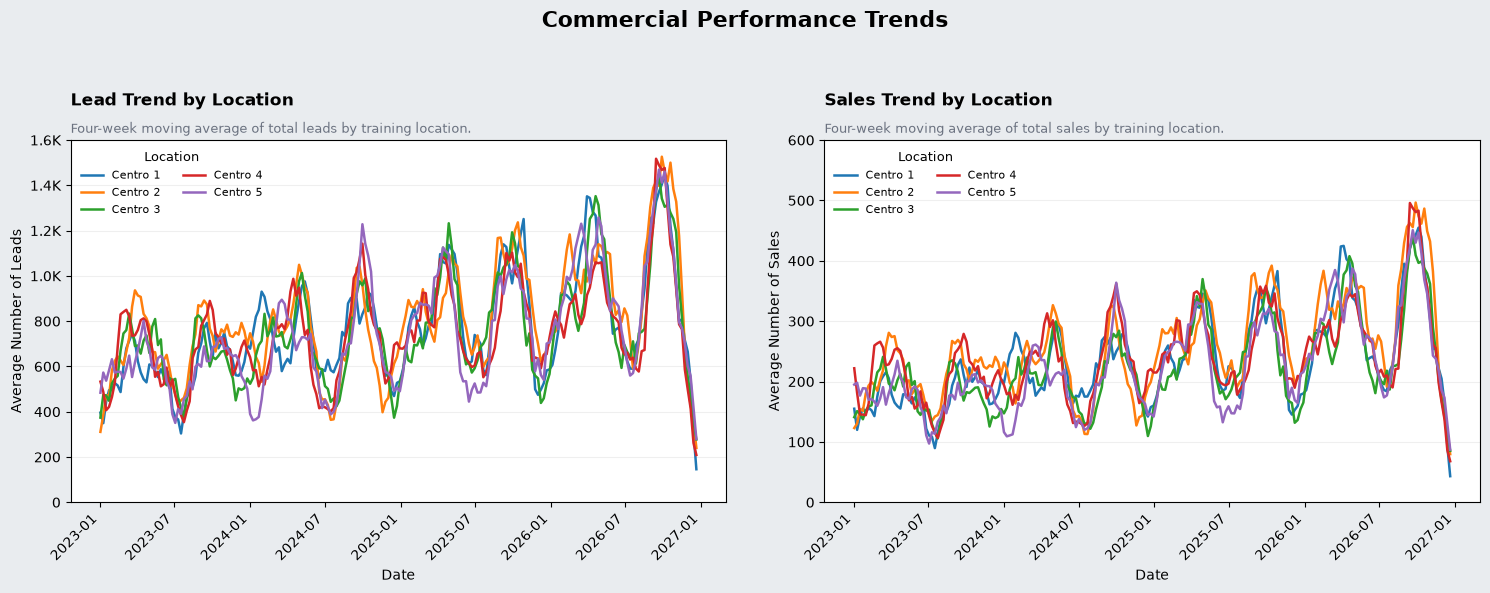

In [434]:
commercial_temporal_trend_charts = {
    "leads": {
        "df": commercial_location_weekly_df,
        "date_column": "date",
        "value_column": "total_leads",
        "group_column": "local",
        "rolling_window": 4,
        "title": "Lead Trend by Location",
        "description": (
            "Four-week moving average of total leads by training location."
        ),
        "ylabel": "Average Number of Leads"
    },

    "sales": {
        "df": commercial_location_weekly_df,
        "date_column": "date",
        "value_column": "total_sales",
        "group_column": "local",
        "rolling_window": 4,
        "title": "Sales Trend by Location",
        "description": (
            "Four-week moving average of total sales by training location."
        ),
        "ylabel": "Average Number of Sales"
    }
}


plot_commercial_trends(
    charts=commercial_temporal_trend_charts,
    title="Commercial Performance Trends",
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

In [435]:
commercial_total_weekly_df = (
    commercial_weekly_df
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        total_leads=(
            "total_leads",
            "sum"
        ),

        total_sales=(
            "total_sales",
            "sum"
        )
    )
    .assign(
        series="Total"
    )
    .sort_values("date")
    .reset_index(drop=True)
)

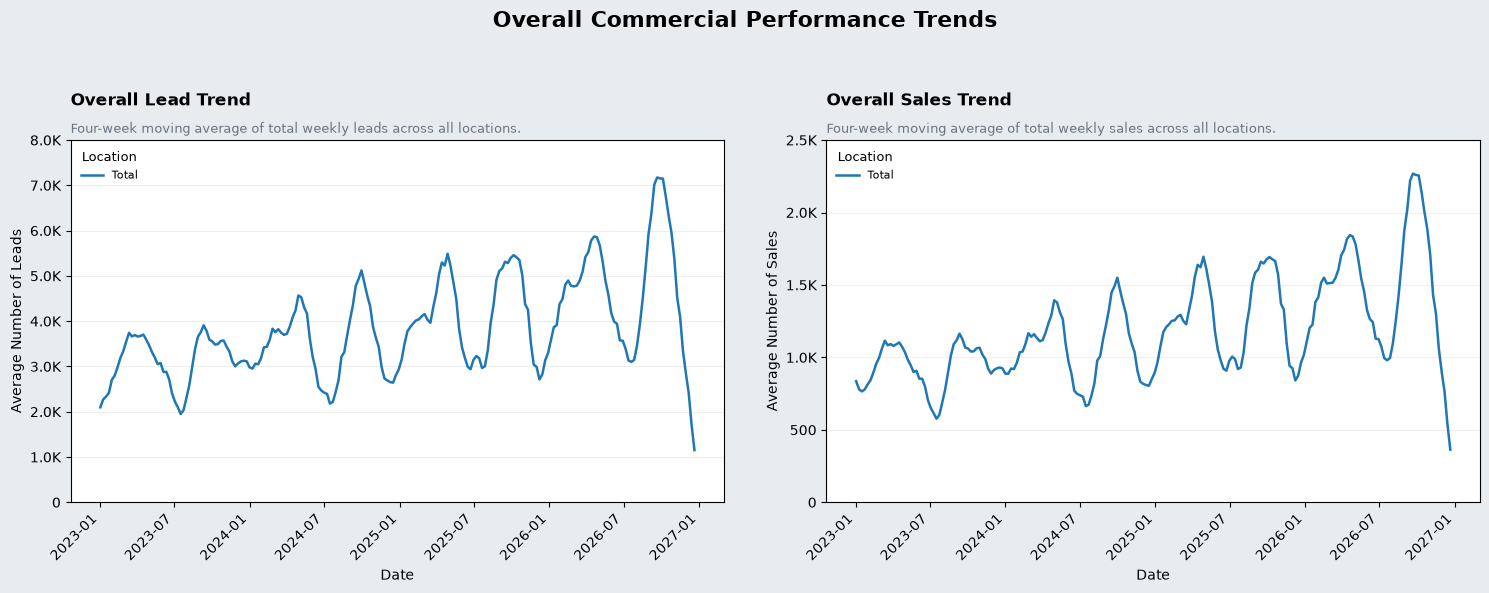

In [436]:
commercial_total_temporal_charts = {
    "leads": {
        "df": commercial_total_weekly_df,
        "date_column": "date",
        "value_column": "total_leads",
        "group_column": "series",
        "rolling_window": 4,
        "title": "Overall Lead Trend",
        "description": (
            "Four-week moving average of total weekly leads across all locations."
        ),
        "ylabel": "Average Number of Leads"
    },

    "sales": {
        "df": commercial_total_weekly_df,
        "date_column": "date",
        "value_column": "total_sales",
        "group_column": "series",
        "rolling_window": 4,
        "title": "Overall Sales Trend",
        "description": (
            "Four-week moving average of total weekly sales across all locations."
        ),
        "ylabel": "Average Number of Sales"
    }
}


plot_commercial_trends(
    charts=commercial_total_temporal_charts,
    title="Overall Commercial Performance Trends",
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

In [437]:
commercial_weekly_df["week_with_leads"] = (
    commercial_weekly_df["total_leads"]
    .gt(0)
    .astype(int)
)


commercial_weekly_df["week_with_sales"] = (
    commercial_weekly_df["total_sales"]
    .gt(0)
    .astype(int)
)

In [438]:
commercial_weekly_df["weekly_conversion_rate"] = (
    commercial_weekly_df["total_sales"]
    .div(
        commercial_weekly_df["total_leads"]
        .where(
            commercial_weekly_df["total_leads"]
            .ne(0)
        )
    )
    .mul(100)
)

In [439]:
commercial_weekly_df["leads_weekly_change"] = (
    commercial_weekly_df
    .groupby(group_columns)["total_leads"]
    .diff()
)


commercial_weekly_df["sales_weekly_change"] = (
    commercial_weekly_df
    .groupby(group_columns)["total_sales"]
    .diff()
)

In [440]:
volume_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_last_13w=(
            "total_leads",
            "sum"
        ),

        total_sales_last_13w=(
            "total_sales",
            "sum"
        ),

        avg_leads_last_13w=(
            "total_leads",
            "mean"
        ),

        avg_sales_last_13w=(
            "total_sales",
            "mean"
        )
    )
)

In [441]:
volume_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_historical=(
            "total_leads",
            "sum"
        ),

        total_sales_historical=(
            "total_sales",
            "sum"
        ),

        avg_leads_historical=(
            "total_leads",
            "mean"
        ),

        avg_sales_historical=(
            "total_sales",
            "mean"
        )
    )
)

In [442]:
commercial_volume_features_df = (
    course_local_combinations
    .merge(
        volume_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        volume_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_volume_features_df

,course_id,course_name,course_area,local,total_leads_last_13w,total_sales_last_13w,avg_leads_last_13w,avg_sales_last_13w,total_leads_historical,total_sales_historical,avg_leads_historical,avg_sales_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,649,185,49.923077,14.230769,12037,3317,61.728205,17.010256
1,CYB,Cibersegurança Básica,Informática,Centro 2,996,296,76.615385,22.769231,13606,3931,69.774359,20.158974
2,CYB,Cibersegurança Básica,Informática,Centro 3,738,203,56.769231,15.615385,11090,2948,56.871795,15.117949
3,CYB,Cibersegurança Básica,Informática,Centro 4,868,265,66.769231,20.384615,16457,4813,84.394872,24.682051
4,CYB,Cibersegurança Básica,Informática,Centro 5,374,108,28.769231,8.307692,9728,2617,49.887179,13.420513
...,...,...,...,...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,227,72,17.461538,5.538462,5506,1628,28.235897,8.348718
116,VND,Vendas e Negociação,Comercial,Centro 2,842,284,64.769231,21.846154,8192,2573,42.010256,13.194872
117,VND,Vendas e Negociação,Comercial,Centro 3,357,104,27.461538,8.000000,4145,1201,21.256410,6.158974
118,VND,Vendas e Negociação,Comercial,Centro 4,608,201,46.769231,15.461538,6709,2154,34.405128,11.046154


In [443]:
conversion_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_period=(
            "total_leads",
            "sum"
        ),

        total_sales_period=(
            "total_sales",
            "sum"
        ),

        avg_conversion_rate_last_13w=(
            "weekly_conversion_rate",
            "mean"
        )
    )
    .assign(
        total_conversion_rate_last_13w=lambda df:
            df["total_sales_period"]
            .div(
                df["total_leads_period"]
                .where(
                    df["total_leads_period"]
                    .ne(0)
                )
            )
            .mul(100)
            .fillna(0),

        avg_conversion_rate_last_13w=lambda df:
            df["avg_conversion_rate_last_13w"]
            .fillna(0)
    )
    .drop(
        columns=[
            "total_leads_period",
            "total_sales_period"
        ]
    )
)

In [444]:
conversion_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        total_leads_period=(
            "total_leads",
            "sum"
        ),

        total_sales_period=(
            "total_sales",
            "sum"
        ),

        avg_conversion_rate_historical=(
            "weekly_conversion_rate",
            "mean"
        )
    )
    .assign(
        total_conversion_rate_historical=lambda df:
            df["total_sales_period"]
            .div(
                df["total_leads_period"]
                .where(
                    df["total_leads_period"]
                    .ne(0)
                )
            )
            .mul(100)
            .fillna(0),

        avg_conversion_rate_historical=lambda df:
            df["avg_conversion_rate_historical"]
            .fillna(0)
    )
    .drop(
        columns=[
            "total_leads_period",
            "total_sales_period"
        ]
    )
)

In [445]:
commercial_conversion_features_df = (
    course_local_combinations
    .merge(
        conversion_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        conversion_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_conversion_features_df

,course_id,course_name,course_area,local,avg_conversion_rate_last_13w,total_conversion_rate_last_13w,avg_conversion_rate_historical,total_conversion_rate_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,27.762944,28.505393,27.143716,27.556700
1,CYB,Cibersegurança Básica,Informática,Centro 2,28.645059,29.718876,28.309350,28.891665
2,CYB,Cibersegurança Básica,Informática,Centro 3,26.440651,27.506775,25.928784,26.582507
3,CYB,Cibersegurança Básica,Informática,Centro 4,30.006196,30.529954,29.468443,29.245914
4,CYB,Cibersegurança Básica,Informática,Centro 5,28.025841,28.877005,26.299404,26.901727
...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,31.828863,31.718062,28.471786,29.567744
116,VND,Vendas e Negociação,Comercial,Centro 2,33.511479,33.729216,31.172940,31.408691
117,VND,Vendas e Negociação,Comercial,Centro 3,26.113832,29.131653,28.102322,28.974668
118,VND,Vendas e Negociação,Comercial,Centro 4,32.198896,33.059211,31.587765,32.106126


In [446]:
regularity_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        pct_with_leads_last_13w=(
            "week_with_leads",
            "mean"
        ),

        pct_with_sales_last_13w=(
            "week_with_sales",
            "mean"
        )
    )
    .assign(
        pct_with_leads_last_13w=lambda df:
            df["pct_with_leads_last_13w"]
            .mul(100),

        pct_with_sales_last_13w=lambda df:
            df["pct_with_sales_last_13w"]
            .mul(100)
    )
)

In [447]:
regularity_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        pct_with_leads_historical=(
            "week_with_leads",
            "mean"
        ),

        pct_with_sales_historical=(
            "week_with_sales",
            "mean"
        )
    )
    .assign(
        pct_with_leads_historical=lambda df:
            df["pct_with_leads_historical"]
            .mul(100),

        pct_with_sales_historical=lambda df:
            df["pct_with_sales_historical"]
            .mul(100)
    )
)

In [448]:
commercial_regularity_features_df = (
    course_local_combinations
    .merge(
        regularity_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        regularity_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_regularity_features_df

,course_id,course_name,course_area,local,pct_with_leads_last_13w,pct_with_sales_last_13w,pct_with_leads_historical,pct_with_sales_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,69.230769,69.230769,81.538462,81.538462
1,CYB,Cibersegurança Básica,Informática,Centro 2,84.615385,84.615385,89.230769,89.230769
2,CYB,Cibersegurança Básica,Informática,Centro 3,84.615385,84.615385,84.615385,84.615385
3,CYB,Cibersegurança Básica,Informática,Centro 4,69.230769,69.230769,93.333333,93.333333
4,CYB,Cibersegurança Básica,Informática,Centro 5,38.461538,38.461538,76.410256,76.410256
...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,46.153846,46.153846,70.256410,69.743590
116,VND,Vendas e Negociação,Comercial,Centro 2,76.923077,76.923077,80.000000,80.000000
117,VND,Vendas e Negociação,Comercial,Centro 3,53.846154,53.846154,56.410256,56.410256
118,VND,Vendas e Negociação,Comercial,Centro 4,76.923077,76.923077,76.923077,76.923077


In [449]:
growth_last_13w_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("last_13w")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        leads_weekly_change_avg_last_13w=(
            "leads_weekly_change",
            "mean"
        ),

        sales_weekly_change_avg_last_13w=(
            "sales_weekly_change",
            "mean"
        )
    )
)

In [450]:
growth_historical_df = (
    commercial_weekly_df
    .loc[
        commercial_weekly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        leads_weekly_change_avg_historical=(
            "leads_weekly_change",
            "mean"
        ),

        sales_weekly_change_avg_historical=(
            "sales_weekly_change",
            "mean"
        )
    )
)

In [451]:
commercial_growth_features_df = (
    course_local_combinations
    .merge(
        growth_last_13w_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        growth_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_growth_features_df

,course_id,course_name,course_area,local,leads_weekly_change_avg_last_13w,sales_weekly_change_avg_last_13w,leads_weekly_change_avg_historical,sales_weekly_change_avg_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,0.000000,0.000000,-0.113402,-0.041237
1,CYB,Cibersegurança Básica,Informática,Centro 2,-12.846154,-3.769231,0.654639,0.180412
2,CYB,Cibersegurança Básica,Informática,Centro 3,-12.846154,-3.384615,0.634021,0.154639
3,CYB,Cibersegurança Básica,Informática,Centro 4,-6.000000,-1.846154,0.314433,0.092784
4,CYB,Cibersegurança Básica,Informática,Centro 5,-4.769231,-1.307692,0.134021,0.020619
...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,-1.153846,-0.384615,0.046392,0.015464
116,VND,Vendas e Negociação,Comercial,Centro 2,-6.307692,-2.000000,0.391753,0.118557
117,VND,Vendas e Negociação,Comercial,Centro 3,-2.923077,-0.846154,0.005155,-0.015464
118,VND,Vendas e Negociação,Comercial,Centro 4,-5.384615,-1.769231,0.309278,0.103093


In [452]:
commercial_features_df = (
    course_local_combinations
    .merge(
        commercial_volume_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_conversion_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_regularity_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_growth_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        ["local", "course_id"]
    )
    .reset_index(drop=True)
)

In [453]:
commercial_features_df = commercial_features_df[
    group_columns + [

        "total_leads_last_13w",
        "total_leads_historical",
        "total_sales_last_13w",
        "total_sales_historical",

        "avg_leads_last_13w",
        "avg_leads_historical",
        "avg_sales_last_13w",
        "avg_sales_historical",

        "total_conversion_rate_last_13w",
        "total_conversion_rate_historical",
        "avg_conversion_rate_last_13w",
        "avg_conversion_rate_historical",

        "pct_with_leads_last_13w",
        "pct_with_leads_historical",
        "pct_with_sales_last_13w",
        "pct_with_sales_historical",

        "leads_weekly_change_avg_last_13w",
        "leads_weekly_change_avg_historical",
        "sales_weekly_change_avg_last_13w",
        "sales_weekly_change_avg_historical"
    ]
]

commercial_features_df = commercial_features_df.round(2)


commercial_features_df

,course_id,course_name,course_area,local,total_leads_last_13w,total_leads_historical,total_sales_last_13w,total_sales_historical,avg_leads_last_13w,avg_leads_historical,...,avg_conversion_rate_last_13w,avg_conversion_rate_historical,pct_with_leads_last_13w,pct_with_leads_historical,pct_with_sales_last_13w,pct_with_sales_historical,leads_weekly_change_avg_last_13w,leads_weekly_change_avg_historical,sales_weekly_change_avg_last_13w,sales_weekly_change_avg_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,649,12037,185,3317,49.92,61.73,...,27.76,27.14,69.23,81.54,69.23,81.54,0.00,-0.11,0.00,-0.04
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,147,4935,49,1548,11.31,25.31,...,33.41,30.62,30.77,68.21,30.77,67.69,-0.54,0.04,-0.15,0.01
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,537,7129,179,2325,41.31,36.56,...,33.16,32.80,61.54,78.46,61.54,78.46,-0.54,-0.05,-0.15,-0.02
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,387,5096,112,1421,29.77,26.13,...,28.34,27.02,69.23,63.08,69.23,63.08,-0.85,-0.03,-0.23,-0.02
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,514,5424,165,1668,39.54,27.82,...,31.30,29.86,76.92,68.21,76.92,68.21,-0.92,-0.04,-0.31,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,197,8261,68,2728,15.15,42.36,...,33.84,32.57,30.77,80.51,30.77,80.51,-1.31,-0.14,-0.46,-0.07
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,254,3540,73,999,19.54,18.15,...,27.83,27.53,61.54,53.85,61.54,53.85,1.54,-0.12,0.38,-0.04
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,596,8851,196,2848,45.85,45.39,...,32.30,31.52,76.92,87.18,76.92,87.18,-1.08,-0.16,-0.31,-0.08
118,TUR,Atendimento Turístico,Turismo,Centro 5,397,4821,125,1446,30.54,24.72,...,30.41,28.84,76.92,67.69,76.92,67.69,-0.23,-0.07,-0.08,-0.03


# Score

In [454]:
score_group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


recent_weight = 0.70
historical_weight = 0.30


dimension_weights = {
    "volume": 0.40,
    "conversion": 0.25,
    "regularity": 0.25,
    "growth": 0.10
}


assert round(sum(dimension_weights.values()), 10) == 1, (
    "Dimension weights must add up to 1."
)


assert recent_weight + historical_weight == 1, (
    "Period weights must add up to 1."
)

In [455]:
def create_percentile_score(series, inverse=False):

    values = pd.to_numeric(series, errors="coerce")

    scores = values.rank(pct=True, method="average", ascending=not inverse).mul(100)

    scores = scores.mask(values.eq(0), 0)

    return scores.fillna(0)

In [456]:
commercial_score_combinations = (
    commercial_features_df[
        score_group_columns
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

In [457]:
commercial_volume_score_df = (
    commercial_features_df[
        score_group_columns + [
            "avg_leads_last_13w",
            "avg_leads_historical",
            "avg_sales_last_13w",
            "avg_sales_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_volume_last_13w_score=lambda df: (
            create_percentile_score(
                df["avg_leads_last_13w"]
            )
            .add(
                create_percentile_score(
                    df["avg_sales_last_13w"]
                )
            )
            .div(2)
        ),

        commercial_volume_historical_score=lambda df: (
            create_percentile_score(
                df["avg_leads_historical"]
            )
            .add(
                create_percentile_score(
                    df["avg_sales_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_volume_last_13w_score",
            "commercial_volume_historical_score"
        ]
    ]
)


commercial_volume_score_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,83.750000,95.833333
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,11.250000,35.416667
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,79.166667,74.583333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,50.416667,32.500000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,75.000000,45.833333
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,19.166667,86.666667
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,25.833333,10.416667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.333333,88.333333
118,TUR,Atendimento Turístico,Turismo,Centro 5,56.458333,30.833333


In [458]:
commercial_conversion_score_df = (
    commercial_features_df[
        score_group_columns + [
            "total_conversion_rate_last_13w",
            "total_conversion_rate_historical",
            "avg_conversion_rate_last_13w",
            "avg_conversion_rate_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_conversion_last_13w_score=lambda df: (
            create_percentile_score(
                df["total_conversion_rate_last_13w"]
            )
            .add(
                create_percentile_score(
                    df["avg_conversion_rate_last_13w"]
                )
            )
            .div(2)
        ),

        commercial_conversion_historical_score=lambda df: (
            create_percentile_score(
                df["total_conversion_rate_historical"]
            )
            .add(
                create_percentile_score(
                    df["avg_conversion_rate_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_conversion_last_13w_score",
            "commercial_conversion_historical_score"
        ]
    ]
)


commercial_conversion_score_df

,course_id,course_name,course_area,local,commercial_conversion_last_13w_score,commercial_conversion_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,10.833333,13.750000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,74.791667,57.291667
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,71.875000,75.625000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,15.833333,13.541667
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,47.083333,46.458333
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,82.916667,77.500000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,12.083333,18.541667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,61.666667,64.583333
118,TUR,Atendimento Turístico,Turismo,Centro 5,35.833333,37.500000


In [459]:
commercial_regularity_score_df = (
    commercial_features_df[
        score_group_columns + [
            "pct_with_leads_last_13w",
            "pct_with_leads_historical",
            "pct_with_sales_last_13w",
            "pct_with_sales_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_regularity_last_13w_score=lambda df: (
            create_percentile_score(
                df["pct_with_leads_last_13w"]
            )
            .add(
                create_percentile_score(
                    df["pct_with_sales_last_13w"]
                )
            )
            .div(2)
        ),

        commercial_regularity_historical_score=lambda df: (
            create_percentile_score(
                df["pct_with_leads_historical"]
            )
            .add(
                create_percentile_score(
                    df["pct_with_sales_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_regularity_last_13w_score",
            "commercial_regularity_historical_score"
        ]
    ]
)


commercial_regularity_score_df

,course_id,course_name,course_area,local,commercial_regularity_last_13w_score,commercial_regularity_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,63.750000,84.375000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,11.250000,42.708333
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,46.666667,75.000000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,63.750000,29.583333
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,81.666667,44.166667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,11.250000,81.041667
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,46.666667,8.750000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,81.666667,94.166667
118,TUR,Atendimento Turístico,Turismo,Centro 5,81.666667,41.458333


In [460]:
commercial_growth_score_df = (
    commercial_features_df[
        score_group_columns + [
            "leads_weekly_change_avg_last_13w",
            "leads_weekly_change_avg_historical",
            "sales_weekly_change_avg_last_13w",
            "sales_weekly_change_avg_historical"
        ]
    ]
    .copy()
    .assign(
        commercial_growth_last_13w_score=lambda df: (
            create_percentile_score(
                df["leads_weekly_change_avg_last_13w"]
                .clip(lower=0)
            )
            .add(
                create_percentile_score(
                    df["sales_weekly_change_avg_last_13w"]
                    .clip(lower=0)
                )
            )
            .div(2)
        ),

        commercial_growth_historical_score=lambda df: (
            create_percentile_score(
                df["leads_weekly_change_avg_historical"]
                .clip(lower=0)
            )
            .add(
                create_percentile_score(
                    df["sales_weekly_change_avg_historical"]
                    .clip(lower=0)
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "commercial_growth_last_13w_score",
            "commercial_growth_historical_score"
        ]
    ]
)


commercial_growth_score_df

,course_id,course_name,course_area,local,commercial_growth_last_13w_score,commercial_growth_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,0.000000,0.000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,0.000000,36.875
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,0.000000,0.000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,0.000000,0.000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,0.000000,0.000
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,0.000000,0.000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,98.333333,0.000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,0.000000,0.000
118,TUR,Atendimento Turístico,Turismo,Centro 5,0.000000,0.000


In [461]:
commercial_dimension_scores_df = (
    commercial_score_combinations
    .merge(
        commercial_volume_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_conversion_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_regularity_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        commercial_growth_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,commercial_growth_last_13w_score,commercial_growth_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,83.750000,95.833333,10.833333,13.750000,63.750000,84.375000,0.000000,0.000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,11.250000,35.416667,74.791667,57.291667,11.250000,42.708333,0.000000,36.875
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,79.166667,74.583333,71.875000,75.625000,46.666667,75.000000,0.000000,0.000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,50.416667,32.500000,15.833333,13.541667,63.750000,29.583333,0.000000,0.000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,75.000000,45.833333,47.083333,46.458333,81.666667,44.166667,0.000000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,19.166667,86.666667,82.916667,77.500000,11.250000,81.041667,0.000000,0.000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,25.833333,10.416667,12.083333,18.541667,46.666667,8.750000,98.333333,0.000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.333333,88.333333,61.666667,64.583333,81.666667,94.166667,0.000000,0.000
118,TUR,Atendimento Turístico,Turismo,Centro 5,56.458333,30.833333,35.833333,37.500000,81.666667,41.458333,0.000000,0.000


In [462]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_last_13w_score=lambda df: (
            df["commercial_volume_last_13w_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["commercial_conversion_last_13w_score"]
                .mul(dimension_weights["conversion"])
            )

            .add(
                df["commercial_regularity_last_13w_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["commercial_growth_last_13w_score"]
                .mul(dimension_weights["growth"])
            )
        ),

        commercial_historical_score=lambda df: (
            df["commercial_volume_historical_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["commercial_conversion_historical_score"]
                .mul(dimension_weights["conversion"])
            )

            .add(
                df["commercial_regularity_historical_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["commercial_growth_historical_score"]
                .mul(dimension_weights["growth"])
            )
        )
    )
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,commercial_growth_last_13w_score,commercial_growth_historical_score,commercial_last_13w_score,commercial_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,83.750000,95.833333,10.833333,13.750000,63.750000,84.375000,0.000000,0.000,52.145833,62.864583
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,11.250000,35.416667,74.791667,57.291667,11.250000,42.708333,0.000000,36.875,26.010417,42.854167
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,79.166667,74.583333,71.875000,75.625000,46.666667,75.000000,0.000000,0.000,61.302083,67.489583
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,50.416667,32.500000,15.833333,13.541667,63.750000,29.583333,0.000000,0.000,40.062500,23.781250
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,75.000000,45.833333,47.083333,46.458333,81.666667,44.166667,0.000000,0.000,62.187500,40.989583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,19.166667,86.666667,82.916667,77.500000,11.250000,81.041667,0.000000,0.000,31.208333,74.302083
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,25.833333,10.416667,12.083333,18.541667,46.666667,8.750000,98.333333,0.000,34.854167,10.989583
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.333333,88.333333,61.666667,64.583333,81.666667,94.166667,0.000000,0.000,69.166667,75.020833
118,TUR,Atendimento Turístico,Turismo,Centro 5,56.458333,30.833333,35.833333,37.500000,81.666667,41.458333,0.000000,0.000,51.958333,32.072917


In [463]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_volume_score=lambda df: (
            df["commercial_volume_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_volume_historical_score"]
                .mul(historical_weight)
            )
        ),

        commercial_conversion_score=lambda df: (
            df["commercial_conversion_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_conversion_historical_score"]
                .mul(historical_weight)
            )
        ),

        commercial_regularity_score=lambda df: (
            df["commercial_regularity_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_regularity_historical_score"]
                .mul(historical_weight)
            )
        ),

        commercial_growth_score=lambda df: (
            df["commercial_growth_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_growth_historical_score"]
                .mul(historical_weight)
            )
        )
    )
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,commercial_growth_last_13w_score,commercial_growth_historical_score,commercial_last_13w_score,commercial_historical_score,commercial_volume_score,commercial_conversion_score,commercial_regularity_score,commercial_growth_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,83.750000,95.833333,10.833333,13.750000,63.750000,84.375000,0.000000,0.000,52.145833,62.864583,87.375000,11.708333,69.937500,0.000000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,11.250000,35.416667,74.791667,57.291667,11.250000,42.708333,0.000000,36.875,26.010417,42.854167,18.500000,69.541667,20.687500,11.062500
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,79.166667,74.583333,71.875000,75.625000,46.666667,75.000000,0.000000,0.000,61.302083,67.489583,77.791667,73.000000,55.166667,0.000000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,50.416667,32.500000,15.833333,13.541667,63.750000,29.583333,0.000000,0.000,40.062500,23.781250,45.041667,15.145833,53.500000,0.000000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,75.000000,45.833333,47.083333,46.458333,81.666667,44.166667,0.000000,0.000,62.187500,40.989583,66.250000,46.895833,70.416667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,19.166667,86.666667,82.916667,77.500000,11.250000,81.041667,0.000000,0.000,31.208333,74.302083,39.416667,81.291667,32.187500,0.000000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,25.833333,10.416667,12.083333,18.541667,46.666667,8.750000,98.333333,0.000,34.854167,10.989583,21.208333,14.020833,35.291667,68.833333
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.333333,88.333333,61.666667,64.583333,81.666667,94.166667,0.000000,0.000,69.166667,75.020833,84.833333,62.541667,85.416667,0.000000
118,TUR,Atendimento Turístico,Turismo,Centro 5,56.458333,30.833333,35.833333,37.500000,81.666667,41.458333,0.000000,0.000,51.958333,32.072917,48.770833,36.333333,69.604167,0.000000


In [464]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_volume_contribution=lambda df:
            df["commercial_volume_score"]
            .mul(dimension_weights["volume"]),

        commercial_conversion_contribution=lambda df:
            df["commercial_conversion_score"]
            .mul(dimension_weights["conversion"]),

        commercial_regularity_contribution=lambda df:
            df["commercial_regularity_score"]
            .mul(dimension_weights["regularity"]),

        commercial_growth_contribution=lambda df:
            df["commercial_growth_score"]
            .mul(dimension_weights["growth"]),

        commercial_base_score=lambda df: (
            df["commercial_last_13w_score"]
            .mul(recent_weight)
            .add(
                df["commercial_historical_score"]
                .mul(historical_weight)
            )
        )
    )
)

In [465]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .assign(
        commercial_pressure_tier=lambda df:
            pd.cut(
                df["commercial_base_score"],
                bins=[
                    0,
                    25,
                    50,
                    75,
                    100
                ],
                labels=[
                    "Low",
                    "Lower-middle",
                    "Upper-middle",
                    "High"
                ],
                include_lowest=True
            ),

        commercial_main_pressure_driver=lambda df:
            df[
                [
                    "commercial_volume_contribution",
                    "commercial_conversion_contribution",
                    "commercial_regularity_contribution",
                    "commercial_growth_contribution"
                ]
            ]
            .idxmax(axis=1)
            .map(
                {
                    "commercial_volume_contribution":
                        "Volume",

                    "commercial_conversion_contribution":
                        "Conversion",

                    "commercial_regularity_contribution":
                        "Regularity",

                    "commercial_growth_contribution":
                        "Growth"
                }
            )
    )
)

In [466]:
commercial_dimension_scores_df[
    "commercial_priority_rank"
] = (
    commercial_dimension_scores_df[
        "commercial_base_score"
    ]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

In [467]:
commercial_dimension_scores_df = (
    commercial_dimension_scores_df
    .round(2)
    .sort_values(
        "commercial_priority_rank"
    )
    .reset_index(drop=True)
)


commercial_dimension_scores_df

,course_id,course_name,course_area,local,commercial_volume_last_13w_score,commercial_volume_historical_score,commercial_conversion_last_13w_score,commercial_conversion_historical_score,commercial_regularity_last_13w_score,commercial_regularity_historical_score,...,commercial_regularity_score,commercial_growth_score,commercial_volume_contribution,commercial_conversion_contribution,commercial_regularity_contribution,commercial_growth_contribution,commercial_base_score,commercial_pressure_tier,commercial_main_pressure_driver,commercial_priority_rank
0,PBI,Power BI e Visualização de Dados,Informática,Centro 4,100.00,99.58,67.08,71.67,97.50,100.00,...,98.25,26.62,39.95,17.11,24.56,2.66,84.29,High,Volume,1
1,HAC,Higiene e Segurança Alimentar,Alimentar,Centro 5,82.92,79.17,93.12,89.58,97.50,75.00,...,90.75,27.56,32.72,23.02,22.69,2.76,81.18,High,Volume,2
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 3,92.29,80.00,79.58,83.33,99.58,88.96,...,96.40,13.62,35.44,20.18,24.10,1.36,81.08,High,Volume,3
3,VND,Vendas e Negociação,Comercial,Centro 2,95.83,84.17,77.71,60.00,81.67,79.17,...,80.92,23.13,36.93,18.10,20.23,2.31,77.57,High,Volume,4
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 2,97.50,55.00,76.88,70.21,99.58,72.50,...,91.46,15.31,33.90,18.72,22.86,1.53,77.01,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SOC,Socorrismo Básico,Saúde e Segurança,Centro 1,6.67,3.75,39.58,28.33,4.17,2.50,...,3.67,17.19,2.32,9.05,0.92,1.72,14.00,Low,Conversion,116
116,GES,Gestão de Equipas,Gestão,Centro 1,10.83,21.67,19.58,8.33,7.50,11.25,...,8.62,18.88,5.63,4.05,2.16,1.89,13.73,Low,Volume,117
117,ING,Inglês Profissional,Línguas,Centro 1,3.33,12.92,31.25,30.83,4.17,3.54,...,3.98,0.00,2.48,7.78,0.99,0.00,11.26,Low,Conversion,118
118,SCI,Segurança Contra Incêndios,Segurança,Centro 5,4.58,15.00,14.58,22.92,4.17,13.75,...,7.04,13.62,3.08,4.27,1.76,1.36,10.48,Low,Conversion,119


In [468]:
commercial_scored_features_df = (
    commercial_features_df
    .merge(
        commercial_dimension_scores_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        "commercial_priority_rank"
    )
    .reset_index(drop=True)
)


commercial_scored_features_df

,course_id,course_name,course_area,local,total_leads_last_13w,total_leads_historical,total_sales_last_13w,total_sales_historical,avg_leads_last_13w,avg_leads_historical,...,commercial_regularity_score,commercial_growth_score,commercial_volume_contribution,commercial_conversion_contribution,commercial_regularity_contribution,commercial_growth_contribution,commercial_base_score,commercial_pressure_tier,commercial_main_pressure_driver,commercial_priority_rank
0,PBI,Power BI e Visualização de Dados,Informática,Centro 4,1214,15366,400,4982,93.38,78.80,...,98.25,26.62,39.95,17.11,24.56,2.66,84.29,High,Volume,1
1,HAC,Higiene e Segurança Alimentar,Alimentar,Centro 5,563,7359,202,2542,43.31,37.74,...,90.75,27.56,32.72,23.02,22.69,2.76,81.18,High,Volume,2
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 3,771,7503,261,2494,59.31,38.48,...,96.40,13.62,35.44,20.18,24.10,1.36,81.08,High,Volume,3
3,VND,Vendas e Negociação,Comercial,Centro 2,842,8192,284,2573,64.77,42.01,...,80.92,23.13,36.93,18.10,20.23,2.31,77.57,High,Volume,4
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 2,912,5759,307,1876,70.15,29.53,...,91.46,15.31,33.90,18.72,22.86,1.53,77.01,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SOC,Socorrismo Básico,Saúde e Segurança,Centro 1,106,2818,33,820,8.15,14.45,...,3.67,17.19,2.32,9.05,0.92,1.72,14.00,Low,Conversion,116
116,GES,Gestão de Equipas,Gestão,Centro 1,154,4505,45,1227,11.85,23.10,...,8.62,18.88,5.63,4.05,2.16,1.89,13.73,Low,Volume,117
117,ING,Inglês Profissional,Línguas,Centro 1,53,3684,16,1077,4.08,18.89,...,3.98,0.00,2.48,7.78,0.99,0.00,11.26,Low,Conversion,118
118,SCI,Segurança Contra Incêndios,Segurança,Centro 5,67,3922,19,1136,5.15,20.11,...,7.04,13.62,3.08,4.27,1.76,1.36,10.48,Low,Conversion,119


In [469]:
tier_order = [
    "Low",
    "Lower-middle",
    "Upper-middle",
    "High"
]

commercial_tier_count_df = (
    commercial_dimension_scores_df[
        "commercial_pressure_tier"
    ]
    .value_counts()
    .reindex(
        tier_order,
        fill_value=0
    )
    .rename_axis(
        "commercial_pressure_tier"
    )
    .reset_index(
        name="commercial_count"
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
)


commercial_tier_count_df

,commercial_pressure_tier,commercial_count,pct_commercial
0,Low,14,11.666667
1,Lower-middle,53,44.166667
2,Upper-middle,45,37.500000
3,High,8,6.666667


In [470]:
commercial_driver_count_df = (
    commercial_dimension_scores_df
    .groupby(
        "commercial_main_pressure_driver",
        as_index=False
    )
    .agg(
        commercial_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        "commercial_count",
        ascending=False
    )
    .reset_index(drop=True)
)


commercial_driver_count_df

,commercial_main_pressure_driver,commercial_count,pct_commercial
0,Volume,78,65.000000
1,Conversion,40,33.333333
2,Regularity,2,1.666667


In [471]:
priority_commercial_df = (
    commercial_dimension_scores_df
    .loc[
        commercial_dimension_scores_df[
            "commercial_pressure_tier"
        ]
        .isin([
            "Upper-middle",
            "High"
        ])
    ]
    .copy()
)

In [472]:
priority_commercial_local_count_df = (
    priority_commercial_df
    .groupby(
        "local",
        as_index=False
    )
    .agg(
        commercial_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        "commercial_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_commercial_local_count_df

,local,commercial_count,pct_commercial
0,Centro 2,14,26.415094
1,Centro 4,12,22.641509
2,Centro 1,11,20.754717
3,Centro 5,9,16.981132
4,Centro 3,7,13.207547


In [473]:
priority_commercial_area_count_df = (
    priority_commercial_df
    .groupby(
        "course_area",
        as_index=False
    )
    .agg(
        commercial_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        "commercial_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_commercial_area_count_df

,course_area,commercial_count,pct_commercial
0,Informática,15,28.301887
1,Segurança,11,20.754717
2,Saúde,6,11.320755
3,Saúde e Segurança,5,9.433962
4,Logística,4,7.547170
5,Comercial,3,5.660377
6,Manutenção,3,5.660377
7,Gestão,2,3.773585
8,Turismo,2,3.773585
9,Alimentar,1,1.886792


In [474]:
priority_commercial_course_count_df = (
    priority_commercial_df
    .groupby(
        [
            "course_id",
            "course_name"
        ],
        as_index=False
    )
    .agg(
        commercial_count=(
            "local",
            "nunique"
        )
    )
    .assign(
        pct_commercial=lambda df:
            df["commercial_count"]
            .div(df["commercial_count"].sum())
            .mul(100)
    )
    .sort_values(
        [
            "commercial_count",
            "course_id"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


priority_commercial_course_count_df

,course_id,course_name,commercial_count,pct_commercial
0,GER,Geriatria e Apoio ao Idoso,5,9.433962
1,PRI,Primeiros Socorros,5,9.433962
2,SST,Saúde e Segurança no Trabalho,5,9.433962
3,CYB,Cibersegurança Básica,4,7.547170
4,EXC,Excel Aplicado à Gestão,4,7.547170
5,LOG,Logística e Gestão de Armazém,4,7.547170
6,PBI,Power BI e Visualização de Dados,4,7.547170
7,SEG,Segurança no Trabalho,4,7.547170
8,MNT,Manutenção Industrial Básica,3,5.660377
9,PYT,Introdução à Programação em Python,3,5.660377


In [475]:
commercial_score_overview_charts = {
    "pressure_tier": {
        "df": commercial_tier_count_df,
        "label_column": "commercial_pressure_tier",
        "metric": "score",
        "sort": False,
        "title": "Commercial Pressure Tier",
        "description": (
            "Distribution of course-location combinations "
            "by commercial pressure level."
        )
    },

    "main_pressure_driver": {
        "df": commercial_driver_count_df,
        "label_column": "commercial_main_pressure_driver",
        "metric": "score",
        "title": "Main Commercial Pressure Driver",
        "description": (
            "Dimension with the highest weighted contribution "
            "to the commercial score."
        )
    },

    "priority_by_location": {
        "df": priority_commercial_local_count_df,
        "label_column": "local",
        "metric": "score",
        "title": "Priority Combinations by Location",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by location."
        )
    },

    "priority_by_course_area": {
        "df": priority_commercial_area_count_df,
        "label_column": "course_area",
        "metric": "score",
        "title": "Priority Combinations by Course Area",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by course area."
        )
    }
}

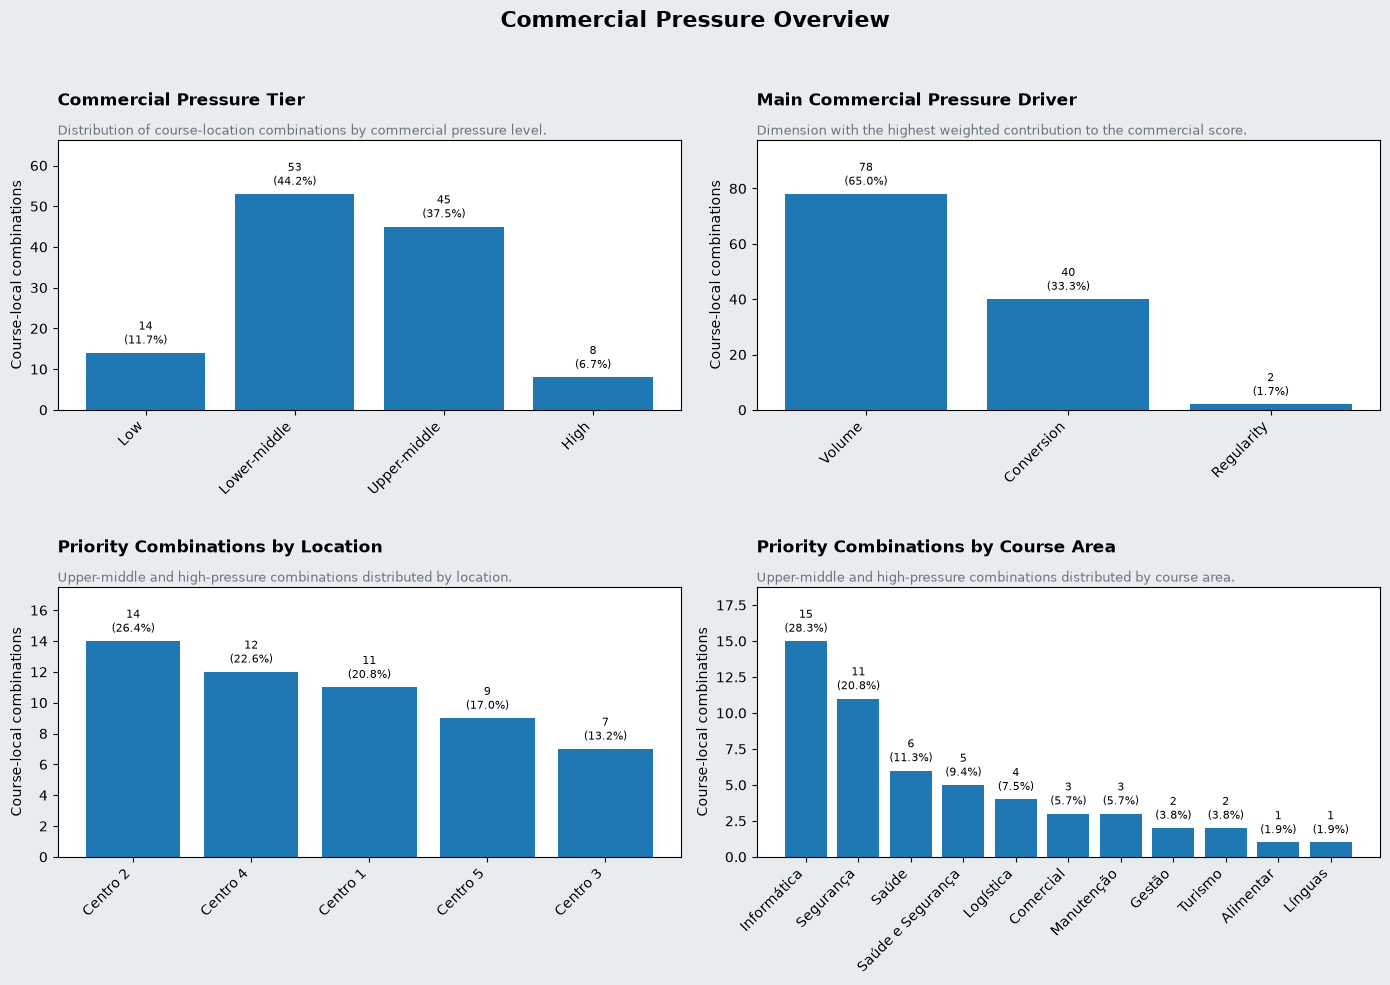

In [476]:
plot_commercial_overview(
    charts=commercial_score_overview_charts,
    title="Commercial Pressure Overview",
    ylabel="Course-local combinations",
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

In [477]:
course_commercial_pressure_charts = {
    "course_pressure": {
        "df": priority_commercial_course_count_df,
        "label_column": "course_id",
        "metric": "score",
        "title": "Courses with the Widest Commercial Pressure",
        "description": (
            "Number of locations where each course belongs to "
            "the upper-middle or high commercial pressure tier."
        )
    }
}

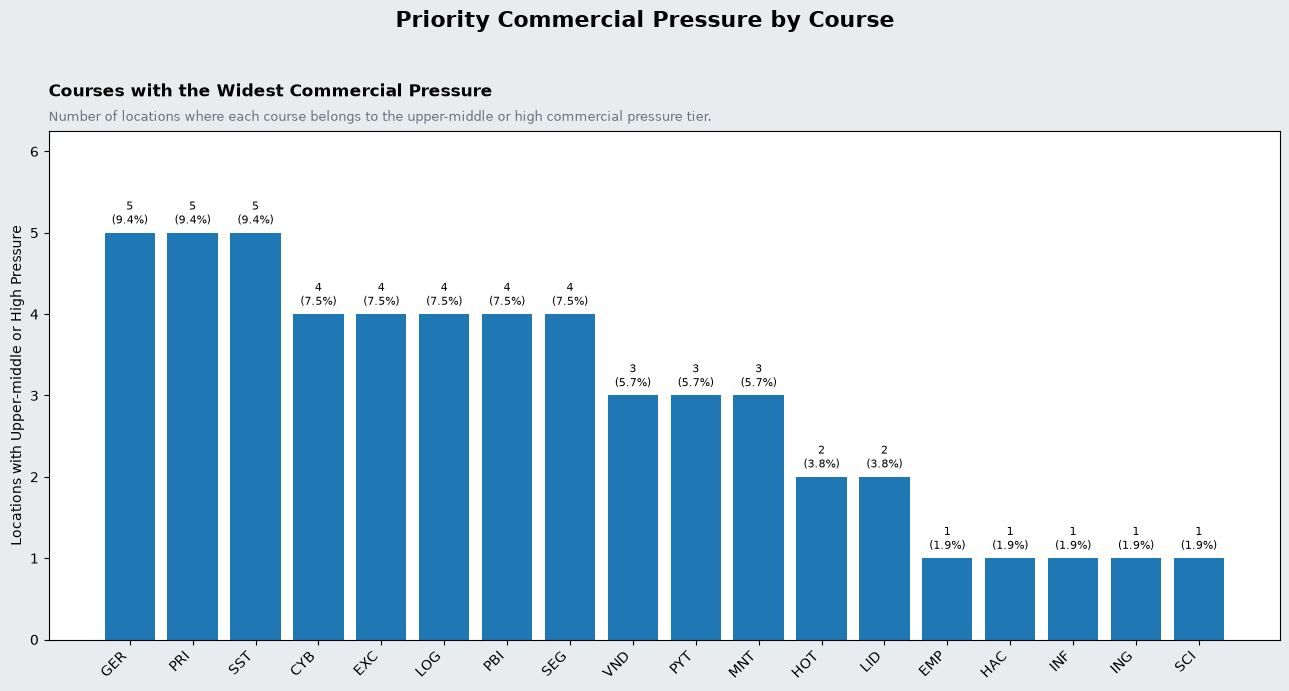

In [478]:
plot_commercial_overview(
    charts=course_commercial_pressure_charts,
    title="Priority Commercial Pressure by Course",
    ylabel="Locations with Upper-middle or High Pressure",
    nrows=1,
    ncols=1,
    figsize=(13, 7)
)